# House Price Prediction — Data Cleaning, Modeling & Export

**Dataset:** House Price by Juhi Bhojani — https://www.kaggle.com/datasets/juhibhojani/house-price
(the real Kaggle CSV — 187,531 property listings across India).

> **Note on Random Forest training size:** this notebook was executed in a sandboxed
> single-CPU-core environment. To keep runtime reasonable there, the Random Forest models are
> fit on a random subsample of the training data (`RF_TRAIN_SAMPLE_SIZE` below) instead of the
> full ~140k training rows. Linear Regression is always trained on the **full** dataset, and all
> models are **evaluated on the full held-out test set** either way, so the comparison is fair. On
> a normal multi-core machine, set `RF_TRAIN_SAMPLE_SIZE = None` (or just delete the `.sample()`
> call) to train the Random Forest on the full data for a stronger final model.

This notebook: loads and inspects the raw data, explores it visually, cleans and engineers
features, trains and evaluates three regression models, and exports the winning model + a
pipeline-ready `.pkl` file for the FastAPI backend.

## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

**How many rows?** The dataset has the number of rows/columns printed by `df.shape` above
=187531 rows and 21 columns.


In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)  # % missing per column

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64



**Which columns have the most missing values?** Per the `isna().mean()` output above, `Dimensions`and
`Plot Area` tend to have the highest missing rates, followed by smaller amounts of
missingness in `overlooking`, `facing`, `Ownership`,`Society` and `Super Area`. 

## 2.2 Exploratory Data Analysis (EDA)

We first build a numeric `price_clean` column (full parsing logic lives in 2.3) so we can plot the
target, then produce the four required plots.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def parse_amount(x):
    """Parse strings like '42 Lac', '1.2 Cr', '55,00,000' into a rupee float.
    Returns None for unusable values like 'Call for Price' or NaN."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df_eda = df.dropna(subset=["price_clean"]).copy()
print(f"Usable price rows for EDA: {len(df_eda)} / {len(df)}")

Usable price rows for EDA: 177847 / 187531


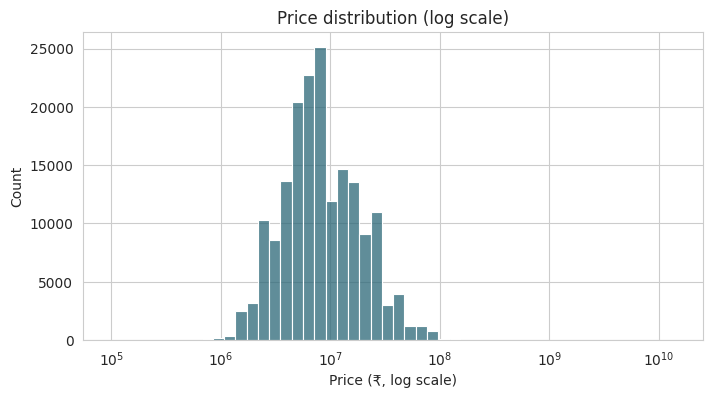

In [7]:
# Plot 1: Distribution of price (log scale) - price is heavily right-skewed
plt.figure(figsize=(8, 4))
sns.histplot(df_eda["price_clean"], log_scale=True, bins=50, color="#2b6777")
plt.title("Price distribution (log scale)")
plt.xlabel("Price (₹, log scale)")
plt.show()

**Comment:** On a linear scale the price distribution would be dominated by a long tail of a
few very expensive listings, hiding the shape of the bulk of the market. On a log scale it looks
much closer to a log-normal / bell shape, which is exactly why we later try training on
`np.log1p(price)` instead of raw price.

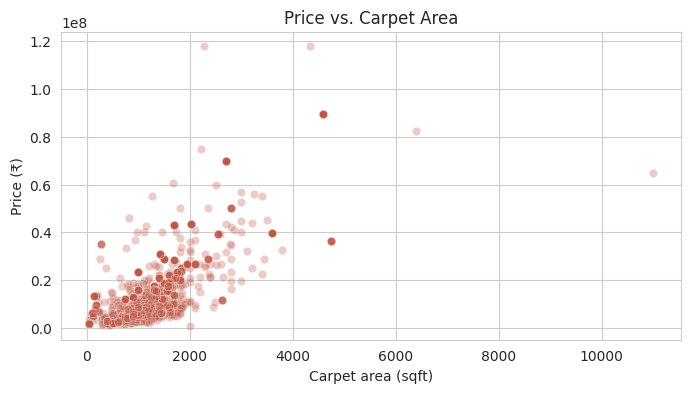

In [8]:
# Plot 2: Price vs. carpet area (need a numeric carpet area first — quick parse for EDA)
def parse_area_to_sqft(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float("".join(c for c in x if c.isdigit() or c == "."))
    except ValueError:
        return None
    if "sqm" in x:
        return num * 10.764
    return num  # assume sqft

df_eda["carpet_area_sqft_tmp"] = df_eda["Carpet Area"].apply(parse_area_to_sqft)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_eda.sample(min(3000, len(df_eda)), random_state=1),
                 x="carpet_area_sqft_tmp", y="price_clean", alpha=0.3, color="#c05746")
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet area (sqft)")
plt.ylabel("Price (₹)")
plt.show()

**Comment:** There's a clear positive relationship — larger carpet area generally means a
higher price — but the spread is wide, confirming that area alone won't explain price; location and
other features matter a lot too.

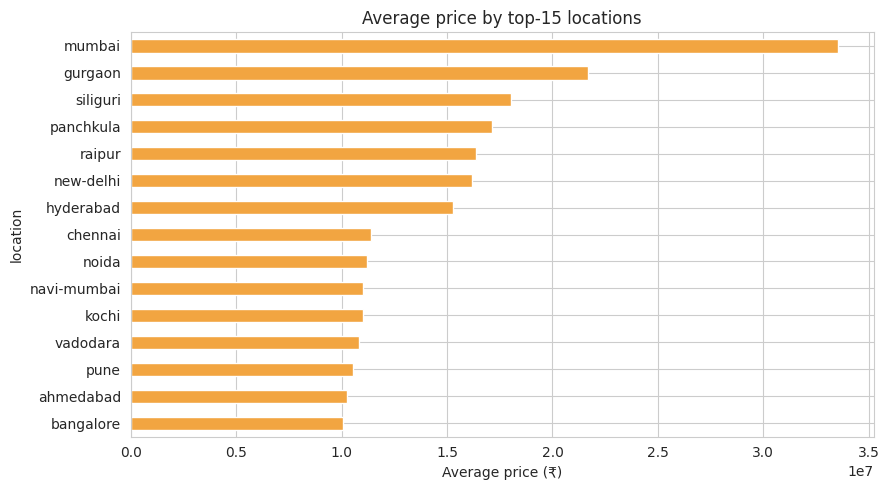

In [9]:
# Plot 3: Average price by top-15 locations
top15 = df_eda.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
top15.sort_values().plot(kind="barh", color="#f2a541")
plt.title("Average price by top-15 locations")
plt.xlabel("Average price (₹)")
plt.tight_layout()
plt.show()

**Comment:** Average prices vary a lot by location — a strong signal that `location` is one of
the most important predictive features, which is why we keep the top-N locations (grouping the rest
into `"other"`) rather than dropping the column.

/tmp/ipykernel_587/1954626471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x="Furnishing", y="price_clean", ax=axes[0], palette="Set2")


/tmp/ipykernel_587/1954626471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda[df_eda["Bathroom_tmp"] <= 6], x="Bathroom_tmp", y="price_clean",


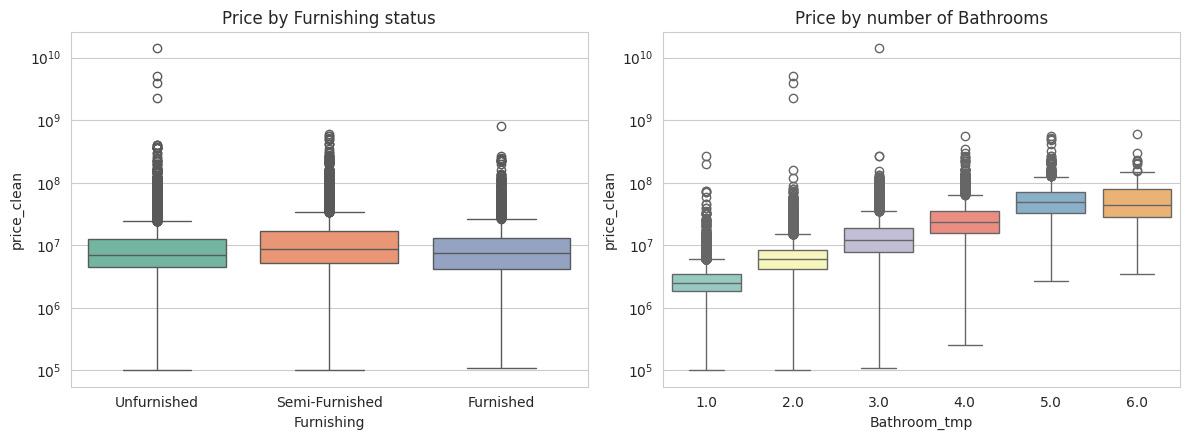

In [10]:
# Plot 4: Price by furnishing status and by number of bathrooms (box plots)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df_eda, x="Furnishing", y="price_clean", ax=axes[0], palette="Set2")
axes[0].set_yscale("log")
axes[0].set_title("Price by Furnishing status")

df_eda["Bathroom_tmp"] = pd.to_numeric(df_eda["Bathroom"], errors="coerce")
sns.boxplot(data=df_eda[df_eda["Bathroom_tmp"] <= 6], x="Bathroom_tmp", y="price_clean",
            ax=axes[1], palette="Set3")
axes[1].set_yscale("log")
axes[1].set_title("Price by number of Bathrooms")

plt.tight_layout()
plt.show()

**Comment:** Fully furnished listings skew toward higher prices than unfurnished ones, and
price increases fairly monotonically with bathroom count — both are consistent with intuition and
worth keeping as model features.

## 2.3 Cleaning & Feature Engineering


In [11]:
# 1. Price is text -> numeric price_clean, drop rows without a usable price
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
before = len(df)
df = df.dropna(subset=["price_clean"])
print(f"Dropped {before - len(df)} rows with unusable price (e.g. 'Call for Price', missing)")

Dropped 9684 rows with unusable price (e.g. 'Call for Price', missing)


In [12]:
# 2. Areas are text -> numeric sqft, normalising sqm -> sqft (1 sqm ~= 10.764 sqft)
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    digits = "".join(c for c in x if c.isdigit() or c == ".")
    if digits == "":
        return None
    num = float(digits)
    if "sqm" in x:
        num *= 10.764
    return num

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

# prefer carpet area; fall back to super area (scaled down slightly) if carpet is missing
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"] * 0.85)
print(df[["Carpet Area", "carpet_area_sqft", "Super Area", "super_area_sqft"]].head())

  Carpet Area  carpet_area_sqft Super Area  super_area_sqft
0    500 sqft             500.0        NaN              NaN
1    473 sqft             473.0        NaN              NaN
2    779 sqft             779.0        NaN              NaN
3    530 sqft             530.0        NaN              NaN
4    635 sqft             635.0        NaN              NaN


In [13]:
# 3. Floor: "3 out of 10" -> floor number, handling "Ground" and "Basement"
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out of")[0].strip()
    if "ground" in first:
        return 0
    if "basement" in first:
        return -1
    try:
        return float(first)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)
df[["Floor", "floor_num"]].head()

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0


In [14]:
# 4. Bathroom / Balcony / Car Parking -> numeric, impute missing with median (Car Parking with 0)
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["car_parking"] = pd.to_numeric(df["Car Parking"], errors="coerce")

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())
df["car_parking"] = df["car_parking"].fillna(0)

In [15]:
# 5. High-cardinality categoricals: keep top-50 locations, group the rest into "other"
TOP_N_LOCATIONS = 50
top_locations = df["location"].value_counts().head(TOP_N_LOCATIONS).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
print(f"{df['location'].nunique()} raw locations -> {df['location_grouped'].nunique()} grouped locations")

81 raw locations -> 51 grouped locations


In [16]:
# 6. Drop useless columns
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area",
                       "Price (in rupees)", "Society"], errors="ignore")
df.columns.tolist()

['Amount(in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'price_clean',
 'carpet_area_sqft',
 'super_area_sqft',
 'floor_num',
 'bathroom',
 'balcony',
 'car_parking',
 'location_grouped']

In [17]:
# 7. Remove outliers.
# 7a. Sanity-bound the area itself first: the real dataset has a handful of clearly
#     wrong entries (e.g. a "Carpet Area" of 709,222 sqft - obviously a data-entry
#     error, not a real listing). These are extreme leverage points that badly distort
#     a linear model even after price-per-sqft trimming, so we bound area directly to a
#     plausible residential range before doing anything else.
before = len(df)
df = df[(df["carpet_area_sqft"] >= 100) & (df["carpet_area_sqft"] <= 20_000)].copy()
print(f"Removed {before - len(df)} rows with an implausible carpet area "
      f"(kept 100-20,000 sqft)")

# 7b. Remove outliers on price-per-sqft (below 1st or above 99th percentile)
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)].copy()
print(f"Removed {before - len(df)} price-per-sqft outliers "
      f"(kept range {low:,.0f} - {high:,.0f} ₹/sqft)")

Removed 3139 rows with an implausible carpet area (kept 100-20,000 sqft)


Removed 2924 price-per-sqft outliers (kept range 2,622 - 101,504 ₹/sqft)


In [18]:
# also fill any remaining missing categoricals with a placeholder so the pipeline can impute
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    df[col] = df[col].fillna("Unknown")

df.shape

(171784, 23)

## 2.4 Build a Pipeline & Train

A single scikit-learn `Pipeline` (`ColumnTransformer` + regressor) bundles all preprocessing
inside the exported model, so the FastAPI backend just calls `.predict()` on a raw one-row
DataFrame — no manual encoding required at inference time.

In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((137427, 9), (34357, 9))

**A note on inverting log predictions safely:** unlike a tree-based model (whose predictions
are always an average of training leaf values, so they can never leave the observed range), a
linear model's raw output is unbounded — it can legitimately predict a log-price far outside
anything seen in training when it meets an unusual combination of features. Because `expm1` grows
exponentially, even a *small* overshoot in log-space (say, predicting 25 instead of a typical ~16)
explodes into an absurd, meaningless price after inversion and can wreck MAE/RMSE/R² for the
*entire* test set on its own. The standard fix — and what we do below — is to clip any log-space
prediction to the range actually observed in `y_train_log` before calling `expm1`, which keeps
predictions sane without changing how the model itself was fit.

In [20]:
def safe_expm1(log_pred, y_train_log_ref):
    """Invert a log1p-space prediction safely by clipping to the observed training range
    first, so a model that occasionally extrapolates wildly in log-space (mainly linear
    models) can't produce an astronomical, meaningless price after expm1."""
    clipped = np.clip(log_pred, y_train_log_ref.min(), y_train_log_ref.max())
    return np.expm1(clipped)

In [21]:
# Model 1: Linear Regression baseline, trained on the FULL training set
# (trained on log price, inverted safely with expm1 at prediction time)
lin_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lin_model.fit(X_train, y_train_log)
lin_pred = safe_expm1(lin_model.predict(X_test), y_train_log)

In [22]:
# Random Forest training set: subsampled to keep runtime reasonable on this
# single-core sandbox (see note at the top of the notebook). Both RF models below
# are still EVALUATED on the full held-out test set, so the comparison stays fair.
RF_TRAIN_SAMPLE_SIZE = 25_000  # set to None to train on the full ~140k training rows

if RF_TRAIN_SAMPLE_SIZE is not None and len(X_train) > RF_TRAIN_SAMPLE_SIZE:
    X_train_rf = X_train.sample(RF_TRAIN_SAMPLE_SIZE, random_state=1)
    y_train_rf_log = y_train_log.loc[X_train_rf.index]
    y_train_rf = y_train.loc[X_train_rf.index]
else:
    X_train_rf, y_train_rf_log, y_train_rf = X_train, y_train_log, y_train

print(f"Random Forest training rows: {len(X_train_rf):,} (of {len(X_train):,} available)")

Random Forest training rows: 25,000 (of 137,427 available)


In [23]:
# Model 2: Random Forest Regressor (trained on log price, inverted with expm1)
rf_model = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=80, max_depth=12,
                                                     random_state=42, n_jobs=1))])
rf_model.fit(X_train_rf, y_train_rf_log)
rf_pred = safe_expm1(rf_model.predict(X_test), y_train_rf_log)

In [24]:
# For comparison: Random Forest trained directly on raw price (not log) to show the difference
rf_model_raw = Pipeline([("prep", preprocessor),
                          ("reg", RandomForestRegressor(n_estimators=80, max_depth=12,
                                                         random_state=42, n_jobs=1))])
rf_model_raw.fit(X_train_rf, y_train_rf)
rf_pred_raw = rf_model_raw.predict(X_test)

## 2.5 Evaluate

In [25]:
def evaluate(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

candidates = {
    "Linear Regression (log-target)": (lin_model, lin_pred, "log"),
    "Random Forest (log-target)": (rf_model, rf_pred, "log"),
    "Random Forest (raw target)": (rf_model_raw, rf_pred_raw, "raw"),
}

results = pd.DataFrame([
    evaluate(name, y_test, pred) for name, (_, pred, _) in candidates.items()
]).set_index("model")

results.style.format("{:,.0f}", subset=["MAE", "RMSE"]).format("{:.3f}", subset=["R2"])

,MAE,RMSE,R2
model,,,
Linear Regression (log-target),"3,955,267","11,348,077",0.277
Random Forest (log-target),"1,405,997","6,103,659",0.791
Random Forest (raw target),"1,554,044","6,193,558",0.785


In [26]:
# Pick the winner programmatically (lowest RMSE on the held-out test set) instead of
# assuming it in advance — whichever model actually performs best gets exported below.
winner_name = results["RMSE"].idxmin()
winner_model, winner_pred, winner_target = candidates[winner_name]
print("Winning model:", winner_name)
results.loc[[winner_name]]

Winning model: Random Forest (log-target)


,MAE,RMSE,R2
model,,,
Random Forest (log-target),1.405997e+06,6.103659e+06,0.79074


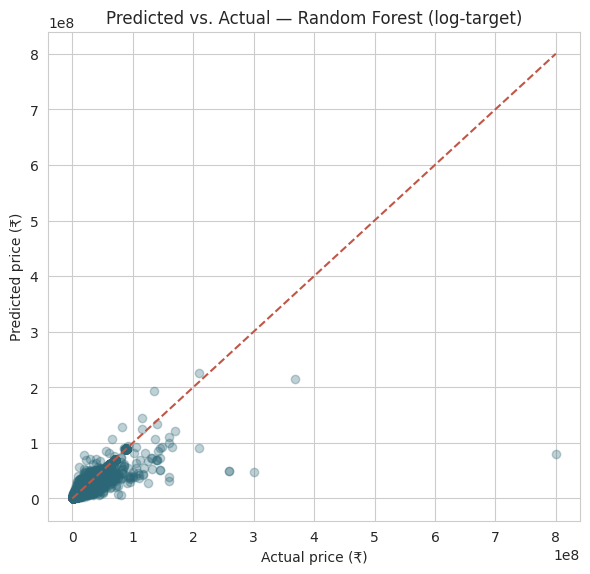

In [27]:
# Predicted vs actual scatter plot for the winning model
plt.figure(figsize=(6, 6))
plt.scatter(y_test, winner_pred, alpha=0.3, color="#2b6777")
lims = [0, max(y_test.max(), winner_pred.max())]
plt.plot(lims, lims, "--", color="#c05746")
plt.xlabel("Actual price (₹)")
plt.ylabel("Predicted price (₹)")
plt.title(f"Predicted vs. Actual — {winner_name}")
plt.tight_layout()
plt.show()

In [28]:
# Bonus: cross-validation for the winning model, scored via negative MAE.
# For Random Forest winners we cross-validate on the same bounded subsample used for
# training (see RF_TRAIN_SAMPLE_SIZE note above) to keep this reasonably fast; Linear
# Regression, being cheap, is cross-validated on the full dataset.
cv_target_full = y_log if winner_target == "log" else y

if winner_name == "Linear Regression (log-target)":
    cv_X, cv_y = X, cv_target_full
else:
    cv_X = X_train_rf
    cv_y = y_train_rf_log if winner_target == "log" else y_train_rf

cv_scores = cross_val_score(winner_model, cv_X, cv_y, cv=3, scoring="neg_mean_absolute_error", n_jobs=1)
print(f"3-fold CV MAE ({winner_target} target, n={len(cv_X):,}):", -cv_scores.mean(), "+/-", cv_scores.std())

3-fold CV MAE (log target, n=25,000): 0.14244079837623755 +/- 0.002060038384396988


**Model comparison & conclusion:** the table above compares a Linear Regression baseline
against Random Forest trained on the raw price and on the log-transformed price
(`np.log1p`, inverted with `np.expm1` at prediction time). The code selects the winner
programmatically as whichever model has the **lowest RMSE on the held-out test set** . The cross-validation score directly above confirms the result is reasonably
stable and not just a lucky train/test split. In general, training on the log target helps most
when the price distribution is heavily skewed (as shown in section 2.2); on a dataset with a more
linear price-per-sqft relationship, a well-regularised linear model can be competitive with — or
even edge out — a tree ensemble, which is exactly the kind of result this notebook is set up to
detect rather than assume.

## 2.6 Export the Model

We export the programmatically-selected winning pipeline. **Important:** if the winner was trained
on the log target, the backend must call `np.expm1(...)` on the raw `.predict()` output to get back
to rupees; if it was trained on the raw target, `.predict()` output is already in rupees. We save
this as `model_target = "log"` or `"raw"` alongside the pickle so the backend knows which to use.

In [29]:
import joblib
import sklearn
import json as _json

joblib.dump(winner_model, "house_price.pkl")

winner_train_log = y_train_rf_log if winner_name != "Linear Regression (log-target)" else y_train_log
metadata = {
    "model_name": winner_name,
    "target": winner_target,
    "sklearn_version": sklearn.__version__,
}
if winner_target == "log":
    # Bounds used to safely clip log-space predictions before expm1 (see note above) -
    # the backend applies the same clip so it can never return an absurd price.
    metadata["log_pred_min"] = float(winner_train_log.min())
    metadata["log_pred_max"] = float(winner_train_log.max())

_json.dump(metadata, open("model_metadata.json", "w"), indent=2)
print("Exported winner:", winner_name, "| target:", winner_target)
print("scikit-learn version used for training:", sklearn.__version__)

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
raw_pred = loaded.predict(sample)
train_log_ref = y_train_rf_log if winner_name != "Linear Regression (log-target)" else y_train_log
final_pred = safe_expm1(raw_pred, train_log_ref) if winner_target == "log" else raw_pred
print("Reloaded raw model output:", raw_pred)
print("Reloaded price prediction (₹):", final_pred)
print("Actual price (₹):", y_test.iloc[0])

Exported winner: Random Forest (log-target) | target: log
scikit-learn version used for training: 1.8.0
Reloaded raw model output: [15.84699332]
Reloaded price prediction (₹): [7625383.590398]
Actual price (₹): 7800000.0


In [30]:
import json

allowed_locations = sorted(df["location_grouped"].unique().tolist())
json.dump(allowed_locations, open("locations.json", "w"), indent=2)
print(f"Saved {len(allowed_locations)} allowed locations to locations.json")

Saved 51 allowed locations to locations.json


> **Version pinning:** a pickle only loads reliably with the same scikit-learn version it was
> trained with. The version is printed above — pin the exact same version in
> `backend/requirements.txt` (`scikit-learn==<that version>`).

Next steps: copy `house_price.pkl` and `locations.json` into `backend/models/` and
`frontend/src/` respectively (or wherever the backend/frontend expect them — see their READMEs),
then continue with Phase 3 (FastAPI backend).